# FDV Corpus Exploration
Terminology and vocabulary analysis across DE / FR / IT language versions.

## Section 0 — Imports & Configuration

In [1]:
%pip install -q sentence-transformers chromadb rank-bm25 langdetect ollama \
             scikit-learn pandas matplotlib stop-words requests

Note: you may need to restart the kernel to use updated packages.


c:\Users\niw\Documents\CAS_NLP_Project\Project_tRAG\.venv\Scripts\python.exe: No module named pip


In [16]:
import re
import json
import urllib.request
import urllib.parse
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.feature_extraction.text import TfidfVectorizer

from chunking import (
    load_documents, build_chunk_records,
    CHUNK_MIN_CHARS, CHUNK_MAX_CHARS
)

# ── Configuration ──────────────────────────────────────────────────────────
LANGUAGES  = ["de", "fr", "it"]
DATA_DIRS  = {
    "de": Path("data/de"),
    "fr": Path("data/fr"),
    "it": Path("data/it"),
}

# Set to True to fetch Wikipedia reference articles (requires internet access)
FETCH_WIKIPEDIA = True

# ── Stopword sets (hardcoded, common function words per language) ───────────
STOPWORDS = {
    "de": {
        "dass", "auch", "wird", "werden", "sind", "eine", "einer", "einem", "eines",
        "einen", "dieser", "diese", "diesem", "diesen", "nach", "beim",
        "durch", "oder", "über", "unter", "nicht", "wenn", "kann", "muss",
        "müssen", "darf", "haben", "sein", "sein", "wurde", "worden", "soweit",
        "sowie", "dabei", "daher", "damit", "dazu", "beim", "ihre", "ihren",
        "ihrer", "ihrem", "sowie", "jedoch", "falls", "sowohl", "werden",
        "welche", "welchen", "welchem", "welcher", "immer", "bereits", "noch",
        "mehr", "sehr", "hier", "dort", "dann", "erst", "zwar", "werden", "sich",
        "kein", "keine", "keines", "keinem",
    },
    "fr": {
        "dans", "pour", "avec", "sont", "cette", "tout", "plus", "doit",
        "doivent", "être", "avoir", "sera", "leur", "leurs", "bien", "même",
        "dont", "lors", "afin", "ainsi", "selon", "entre", "peut", "peuvent",
        "aussi", "donc", "mais", "comme", "toute", "tous", "toutes", "sans",
        "sous", "avant", "après", "vers", "chez", "soit", "autre", "autres",
        "lors", "celui", "celle", "ceux", "celles", "quand", "alors", "plus",
        "faut",
    },
    "it": {
        "sono", "viene", "deve", "devono", "essere", "dalla", "dello", "degli",
        "delle", "nella", "negli", "nelle", "anche", "ogni", "questo", "questi",
        "alla", "alle", "agli", "durante", "mentre", "prima", "dopo", "sempre",
        "però", "oppure", "senza", "quando", "come", "perché", "quindi",
        "quella", "quelli", "quelle", "quale", "quali", "tale", "tali",
        "solo", "solo", "altre", "altri", "altra", "altro", "molti", "molto",
        "dell", "della",
    },
}

# Tokenizer for exploration: lowercase, 4+ chars, Latin-extended range
TOKEN_RE = re.compile(r"[a-z\u00c0-\u024f]{4,}")

def tokenize(text: str) -> list:
    return TOKEN_RE.findall(text.lower())

def content_words(tokens: list, lang: str) -> list:
    stops = STOPWORDS.get(lang, set())
    return [t for t in tokens if t not in stops]

print("Configuration loaded.")

Configuration loaded.


In [2]:
# Load all documents and build chunk records
all_docs = []
for lang in LANGUAGES:
    docs = load_documents(DATA_DIRS[lang], lang)
    all_docs.extend(docs)
    print(f"  {lang}: {len(docs)} documents")

chunk_records = build_chunk_records(all_docs)

# Organise by language for convenience
docs_by_lang   = {lang: [d for d in all_docs      if d["language"] == lang] for lang in LANGUAGES}
chunks_by_lang = {lang: [c for c in chunk_records if c["language"] == lang] for lang in LANGUAGES}

print(f"\nTotal documents : {len(all_docs)}")
print(f"Total chunks    : {len(chunk_records)}")

  de: 15 documents
  fr: 15 documents
  it: 15 documents

Total documents : 45
Total chunks    : 14039


## Section 1 — Document Overview


  Language: DE


Regulation,Title,Characters,Words,Chunks
R 300.1,Grundlagen,56400,6947,1457
R 300.10,Formulare,4013,533,11
R 300.11,Schalten und Erden von Fahrleitungen,4894,598,11
R 300.12,Arbeiten im Gleisbereich,37039,4841,103
R 300.13,Lokfuehrer in,15839,2053,46
R 300.14,Bremsen,67096,8675,342
R 300.15,Besondere Betriebsformen,11069,1470,27
R 300.2,Signale,88160,10819,1193
R 300.3,Kommunikation Anordnungen und Uebermittlung,44399,5603,302
R 300.4,Rangierbewegungen,93109,12225,212


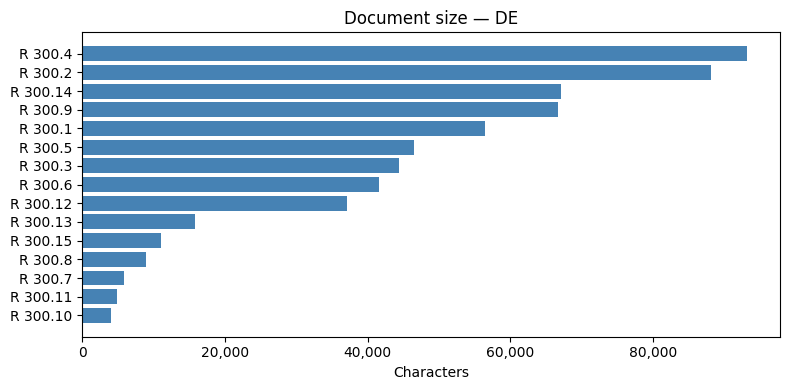


  Language: FR


Regulation,Title,Characters,Words,Chunks
R 300.1,Principes de base,62320,9147,1539
R 300.10,Formulaires,4278,644,49
R 300.11,Enclenchement declenchement et mise a la terre,5796,869,13
R 300.12,Travaux sur et aux abords des voies,39238,6131,303
R 300.13,Mecanicien ne de locomotive,16972,2694,46
R 300.14,Freins,75077,12086,253
R 300.15,Formes particulieres d exploitation,11818,1922,28
R 300.2,Signaux,103665,15499,1342
R 300.3,Communication annonces et transmissions,47484,7443,401
R 300.4,Mouvements de manoeuvre,103230,16432,347


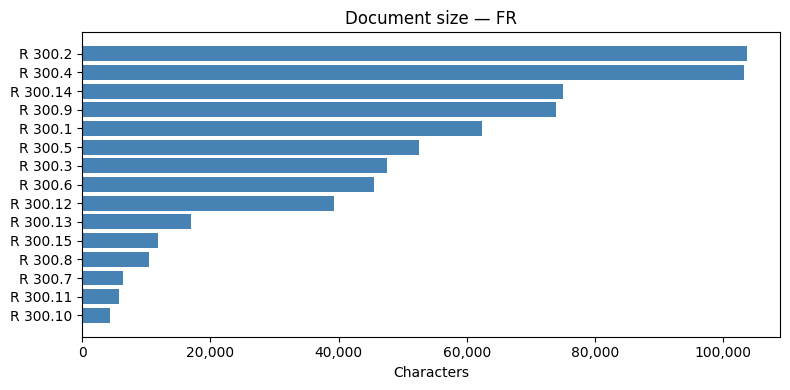


  Language: IT


Regulation,Title,Characters,Words,Chunks
R 300.1,Basi,23206,3349,142
R 300.10,Formulari,4174,609,11
R 300.11,Commutazione e messa a terra di linee di contatto,5345,785,10
R 300.12,Lavori nella zona dei binari,38553,5855,102
R 300.13,Macchinista,16818,2584,46
R 300.14,Freni,73529,11344,352
R 300.15,Forme d esercizio particolari,11542,1759,28
R 300.2,Segnali,98071,14336,1173
R 300.3,Comunicazione disposizioni e trasmissione,46586,6748,286
R 300.4,Movimenti di manovra,99079,15399,232


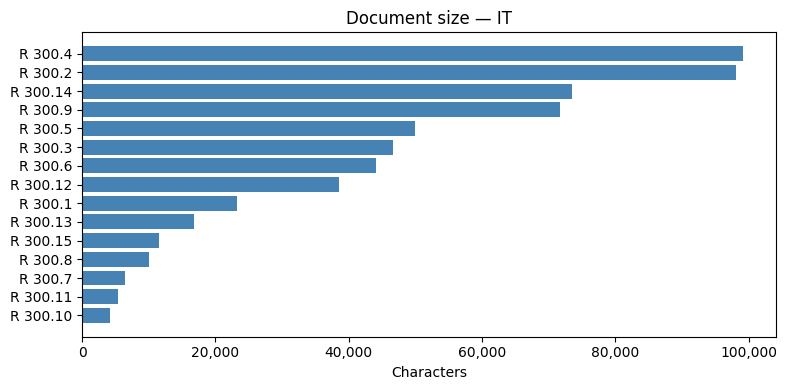

In [3]:
for lang in LANGUAGES:
    rows = []
    for doc in docs_by_lang[lang]:
        doc_chunks = [c for c in chunks_by_lang[lang]
                      if c["source_file"] == doc["source_file"]]
        rows.append({
            "Regulation":  doc["regulation_number"],
            "Title":       doc["document_title"],
            "Characters":  len(doc["text"]),
            "Words":       len(doc["text"].split()),
            "Chunks":      len(doc_chunks),
        })
    df = pd.DataFrame(rows).sort_values("Regulation")
    totals = pd.DataFrame([{
        "Regulation": "TOTAL",
        "Title": "",
        "Characters": df["Characters"].sum(),
        "Words":      df["Words"].sum(),
        "Chunks":     df["Chunks"].sum(),
    }])
    df_display = pd.concat([df, totals], ignore_index=True)

    print(f"\n{'='*60}")
    print(f"  Language: {lang.upper()}")
    print(f"{'='*60}")
    display(df_display.style.hide(axis="index"))

    # Horizontal bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    df_sorted = df.sort_values("Characters")
    ax.barh(df_sorted["Regulation"], df_sorted["Characters"], color="steelblue")
    ax.set_xlabel("Characters")
    ax.set_title(f"Document size — {lang.upper()}")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    plt.show()

In [4]:
# Combined summary across all three languages
combined_rows = []
for lang in LANGUAGES:
    for doc in docs_by_lang[lang]:
        doc_chunks = [c for c in chunks_by_lang[lang]
                      if c["source_file"] == doc["source_file"]]
        combined_rows.append({
            "Language":   lang.upper(),
            "Regulation": doc["regulation_number"],
            "Characters": len(doc["text"]),
            "Words":      len(doc["text"].split()),
            "Chunks":     len(doc_chunks),
        })

df_combined = pd.DataFrame(combined_rows)
display(df_combined.groupby("Language")[["Characters", "Words", "Chunks"]]
        .sum().rename(columns=str.capitalize))

,Characters,Words,Chunks
Language,,,
DE,591581,76065,4851
FR,658663,103162,5718
IT,599027,91086,3470


## Section 2 — Chunk Size Distribution

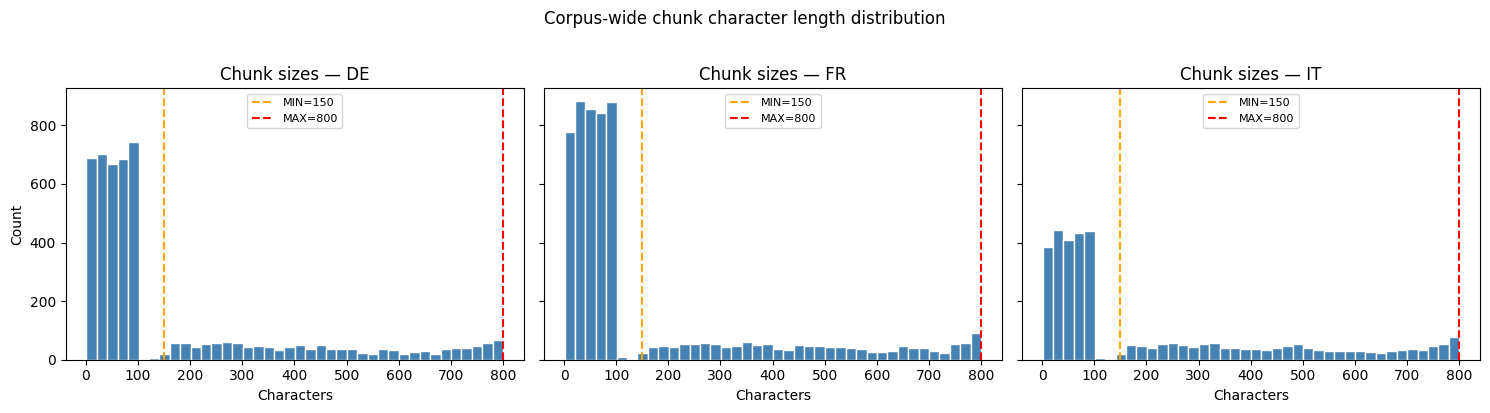

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, lang in zip(axes, LANGUAGES):
    sizes = [len(c["text"]) for c in chunks_by_lang[lang]]
    ax.hist(sizes, bins=40, color="steelblue", edgecolor="white")
    ax.axvline(CHUNK_MIN_CHARS, color="orange", linestyle="--",
               label=f"MIN={CHUNK_MIN_CHARS}")
    ax.axvline(CHUNK_MAX_CHARS, color="red",    linestyle="--",
               label=f"MAX={CHUNK_MAX_CHARS}")
    ax.set_title(f"Chunk sizes — {lang.upper()}")
    ax.set_xlabel("Characters")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Count")
plt.suptitle("Corpus-wide chunk character length distribution", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\niw\AppData\Local\Temp\ipykernel_7884\3737308966.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=regs, vert=True)


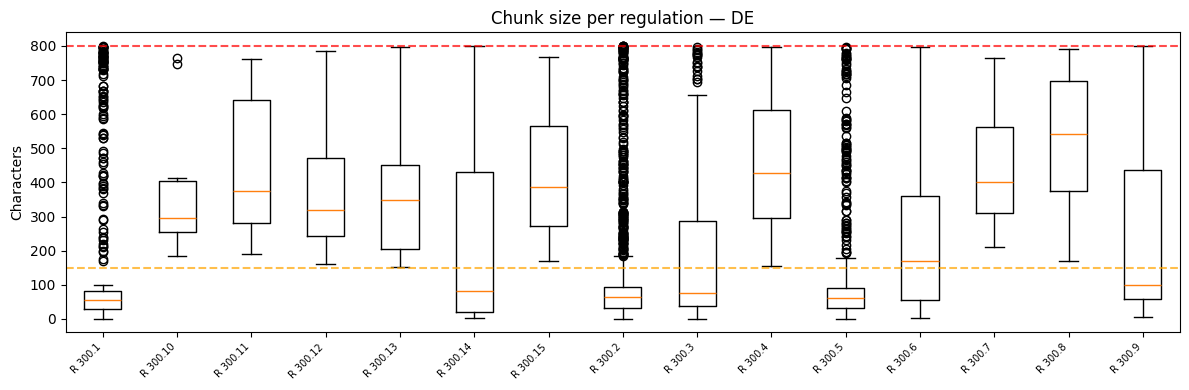

C:\Users\niw\AppData\Local\Temp\ipykernel_7884\3737308966.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=regs, vert=True)


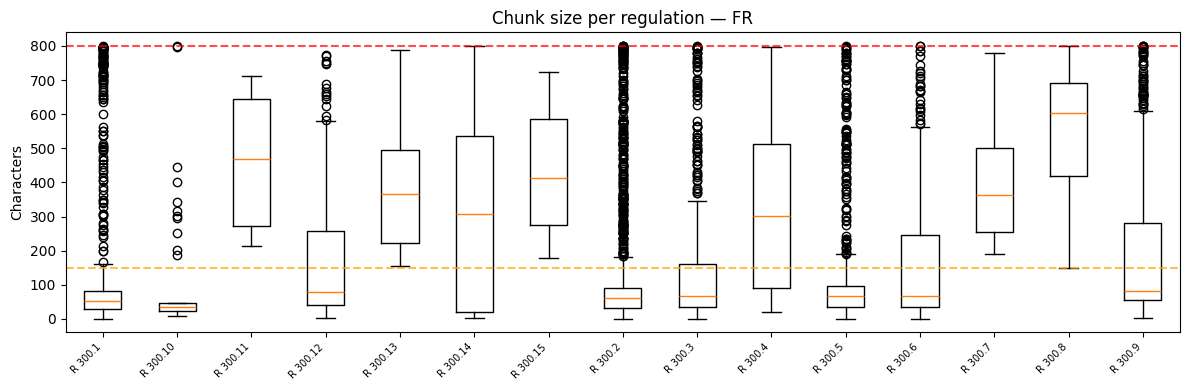

C:\Users\niw\AppData\Local\Temp\ipykernel_7884\3737308966.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=regs, vert=True)


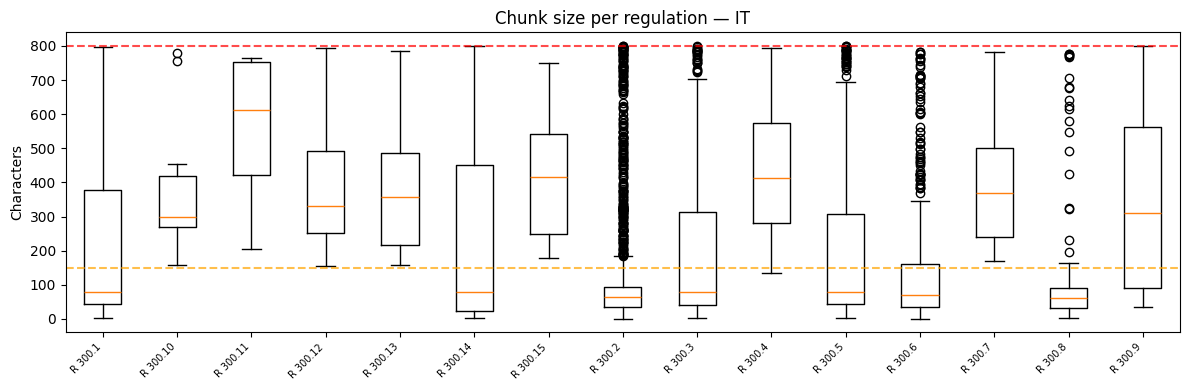

In [6]:
# Per-document boxplot within each language
for lang in LANGUAGES:
    reg_sizes = {}
    for c in chunks_by_lang[lang]:
        reg = c["regulation_number"]
        reg_sizes.setdefault(reg, []).append(len(c["text"]))

    regs  = sorted(reg_sizes.keys())
    data  = [reg_sizes[r] for r in regs]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.boxplot(data, labels=regs, vert=True)
    ax.axhline(CHUNK_MIN_CHARS, color="orange", linestyle="--", alpha=0.7)
    ax.axhline(CHUNK_MAX_CHARS, color="red",    linestyle="--", alpha=0.7)
    ax.set_title(f"Chunk size per regulation — {lang.upper()}")
    ax.set_ylabel("Characters")
    ax.set_xticklabels(regs, rotation=45, ha="right", fontsize=7)
    plt.tight_layout()
    plt.show()

## Section 3 — Sentence Length Distribution

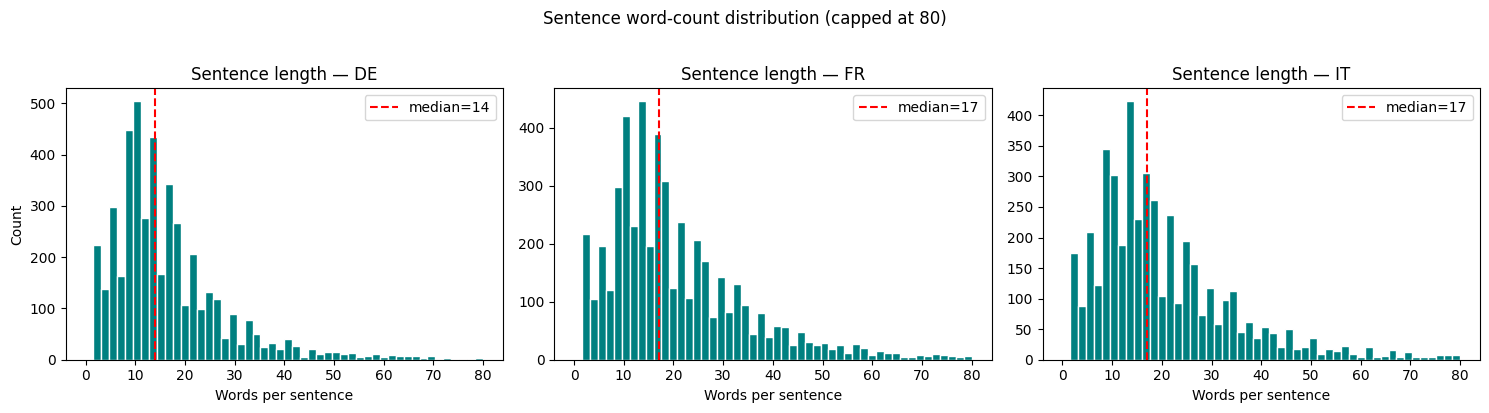

  DE: median=14.0 words/sentence, mean=22.1, n=4,620
  FR: median=17.0 words/sentence, mean=28.1, n=5,096
  IT: median=17.0 words/sentence, mean=24.6, n=4,576


In [7]:
_SENT_RE = re.compile(r"[.!?]+\s+")

def sentence_word_counts(text: str) -> list:
    sentences = _SENT_RE.split(text)
    return [len(s.split()) for s in sentences if len(s.split()) > 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, lang in zip(axes, LANGUAGES):
    all_text = " ".join(c["text"] for c in chunks_by_lang[lang])
    word_counts = sentence_word_counts(all_text)
    median_wc = np.median(word_counts)
    ax.hist(word_counts, bins=50, color="teal", edgecolor="white", range=(0, 80))
    ax.axvline(median_wc, color="red", linestyle="--",
               label=f"median={median_wc:.0f}")
    ax.set_title(f"Sentence length — {lang.upper()}")
    ax.set_xlabel("Words per sentence")
    ax.legend()
axes[0].set_ylabel("Count")
plt.suptitle("Sentence word-count distribution (capped at 80)", y=1.02)
plt.tight_layout()
plt.show()

for lang in LANGUAGES:
    all_text = " ".join(c["text"] for c in chunks_by_lang[lang])
    wcs = sentence_word_counts(all_text)
    print(f"  {lang.upper()}: median={np.median(wcs):.1f} words/sentence, "
          f"mean={np.mean(wcs):.1f}, n={len(wcs):,}")

## Section 4 — Vocabulary & Automatic Term Discovery

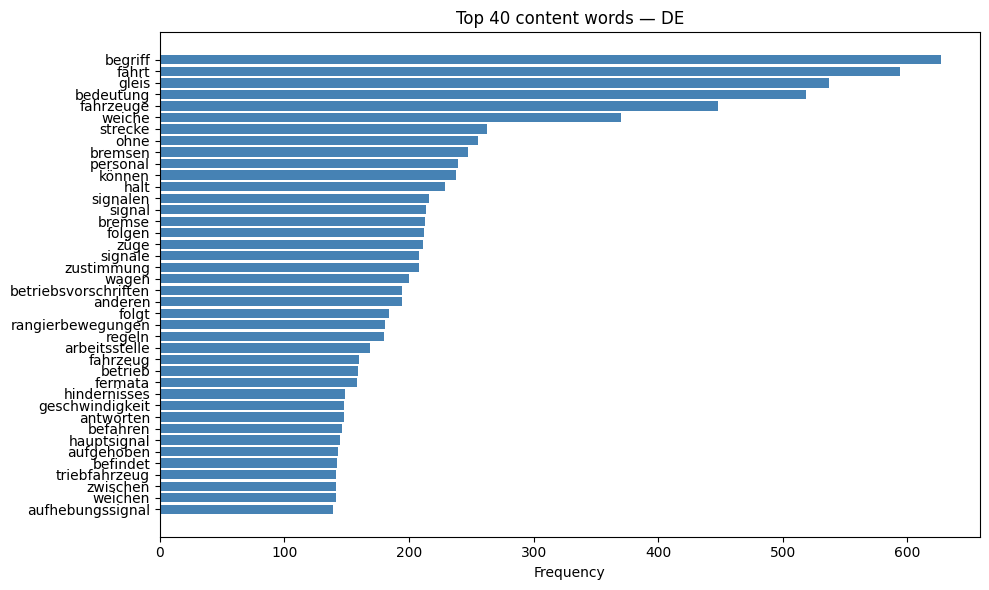

  DE: 8,131 unique content word types


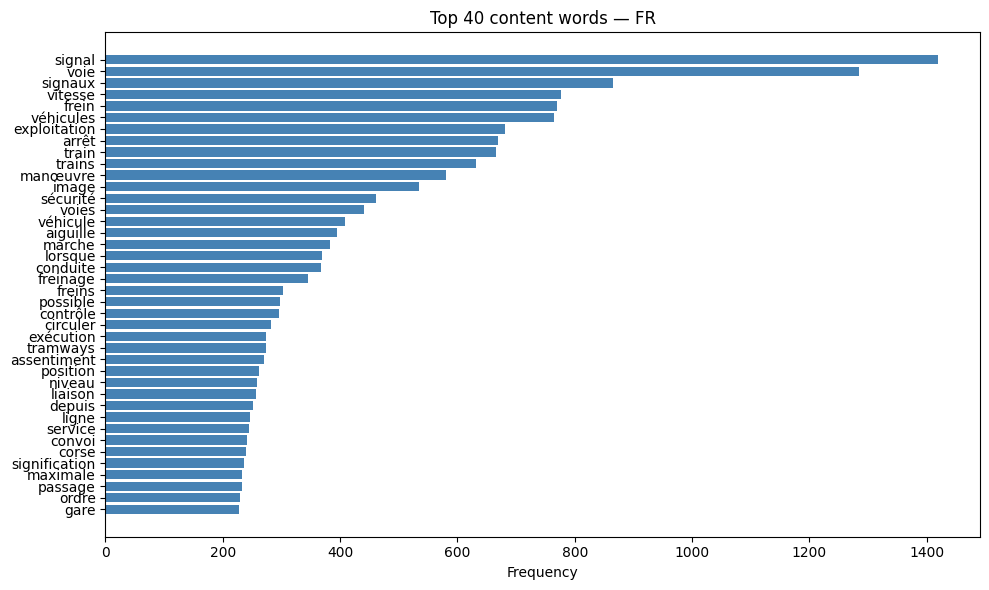

  FR: 5,787 unique content word types


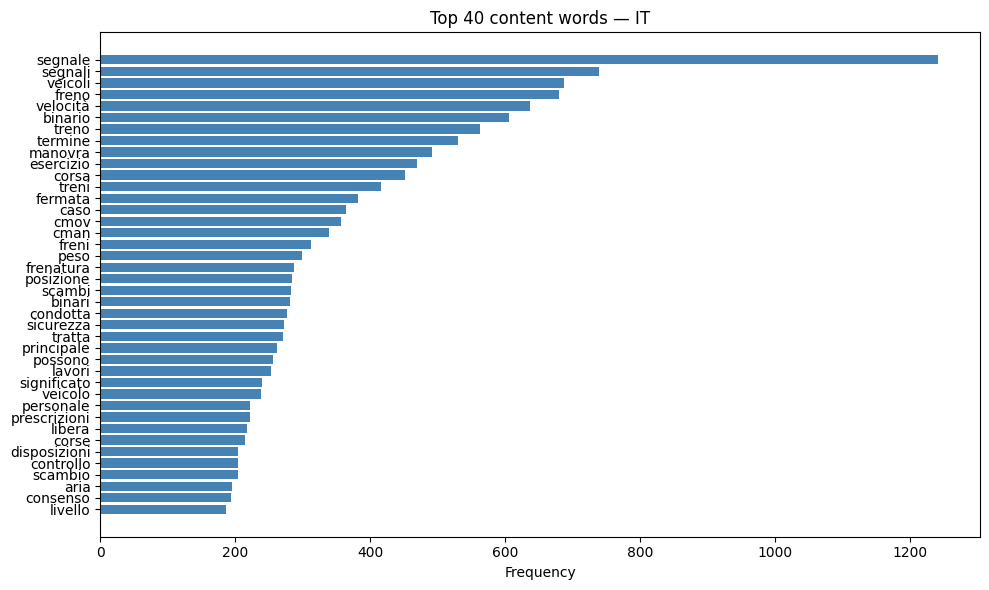

  IT: 5,183 unique content word types


In [17]:
vocab_stats = {}

for lang in LANGUAGES:
    all_text  = " ".join(c["text"] for c in chunks_by_lang[lang])
    tokens    = tokenize(all_text)
    cw        = content_words(tokens, lang)
    freq      = Counter(cw)
    top40     = freq.most_common(40)
    vocab_stats[lang] = {"freq": freq, "types": len(set(cw)), "tokens": len(cw)}

    words, counts = zip(*top40)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(list(reversed(words)), list(reversed(counts)), color="steelblue")
    ax.set_title(f"Top 40 content words — {lang.upper()}")
    ax.set_xlabel("Frequency")
    plt.tight_layout()
    plt.show()

    print(f"  {lang.upper()}: {vocab_stats[lang]['types']:,} unique content word types")

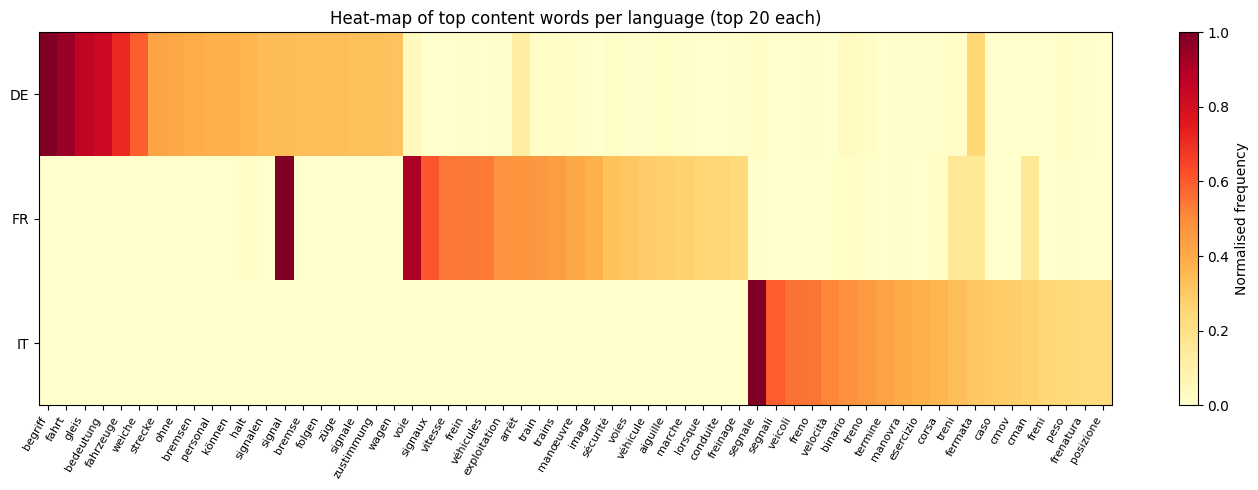

In [18]:
# Grouped bar: top-20 terms per language side by side
top_n = 20
top_terms_per_lang = {
    lang: [w for w, _ in vocab_stats[lang]["freq"].most_common(top_n)]
    for lang in LANGUAGES
}
all_top = list(dict.fromkeys(
    w for lang in LANGUAGES for w in top_terms_per_lang[lang]
))

matrix = np.array([
    [vocab_stats[lang]["freq"].get(w, 0) for w in all_top]
    for lang in LANGUAGES
])

# Normalise per language for comparability
matrix_norm = matrix / matrix.max(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(matrix_norm, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(LANGUAGES)))
ax.set_yticklabels([l.upper() for l in LANGUAGES])
ax.set_xticks(range(len(all_top)))
ax.set_xticklabels(all_top, rotation=60, ha="right", fontsize=8)
plt.colorbar(im, ax=ax, label="Normalised frequency")
ax.set_title(f"Heat-map of top content words per language (top {top_n} each)")
plt.tight_layout()
plt.show()

## Section 5 — Terminology Density

,language,regulation,ttr,avg_word_length,token_count
10,DE,R 300.11,0.612,9.29,379
6,DE,R 300.7,0.579,9.21,456
7,DE,R 300.8,0.558,8.80,745
12,DE,R 300.13,0.535,8.93,1227
9,DE,R 300.10,0.521,8.44,328
0,DE,R 300.1,0.417,9.01,4565
14,DE,R 300.15,0.395,8.54,892
2,DE,R 300.3,0.378,8.84,3417
13,DE,R 300.14,0.317,8.88,5323
4,DE,R 300.5,0.298,8.85,3550


C:\Users\niw\AppData\Local\Temp\ipykernel_7884\616202476.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
C:\Users\niw\AppData\Local\Temp\ipykernel_7884\616202476.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)


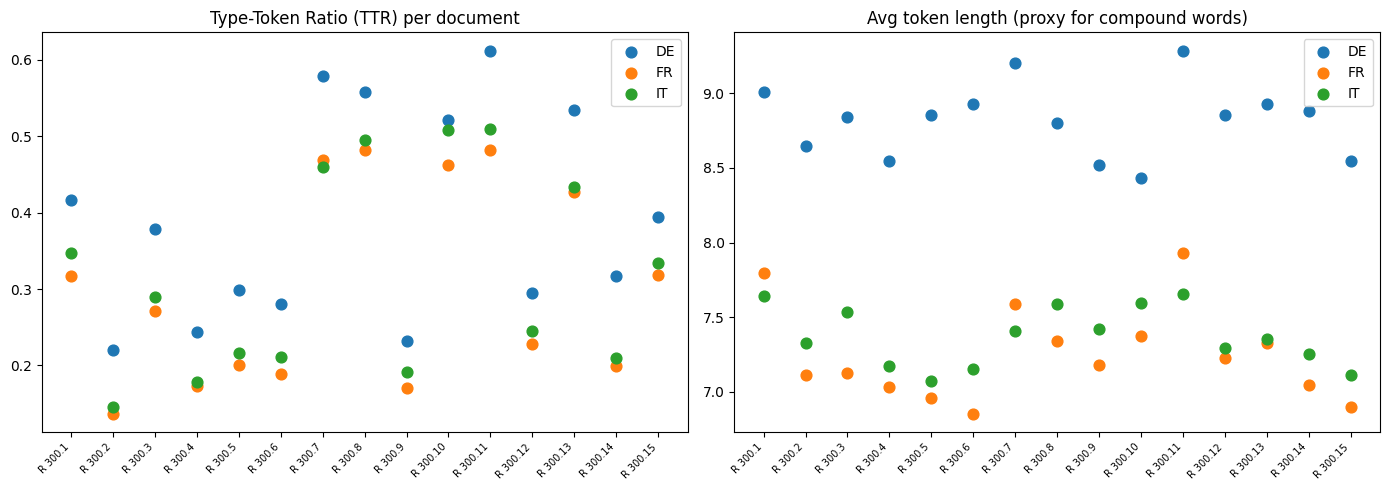

In [19]:
density_rows = []
for lang in LANGUAGES:
    for doc in docs_by_lang[lang]:
        tokens = tokenize(doc["text"])
        if not tokens:
            continue
        ttr      = len(set(tokens)) / len(tokens)
        avg_wlen = np.mean([len(t) for t in tokens])
        density_rows.append({
            "language":         lang.upper(),
            "regulation":       doc["regulation_number"],
            "ttr":              ttr,
            "avg_word_length":  avg_wlen,
            "token_count":      len(tokens),
        })

df_density = pd.DataFrame(density_rows)
display(df_density.sort_values(["language", "ttr"], ascending=[True, False])
        .style.format({"ttr": "{:.3f}", "avg_word_length": "{:.2f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [
    (axes[0], "ttr",             "Type-Token Ratio (TTR) per document"),
    (axes[1], "avg_word_length", "Avg token length (proxy for compound words)"),
]:
    for lang in LANGUAGES:
        subset = df_density[df_density["language"] == lang.upper()]
        ax.scatter(subset["regulation"], subset[metric], label=lang.upper(), s=60)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
    ax.legend()
plt.tight_layout()
plt.show()

## Section 6 — TF-IDF Signatures per Document & Language

In [20]:
TOP_TFIDF = 8

for lang in LANGUAGES:
    lang_chunks = chunks_by_lang[lang]
    texts       = [c["text"] for c in lang_chunks]

    stops_list  = list(STOPWORDS[lang])

    vect = TfidfVectorizer(
        token_pattern=r"(?u)\b[a-z\u00c0-\u024f]{4,}\b",
        lowercase=True,
        min_df=2,
        sublinear_tf=True,
        stop_words=stops_list,
    )
    X            = vect.fit_transform(texts)
    feature_names = np.array(vect.get_feature_names_out())

    # Group chunks by regulation
    regs = sorted(set(c["regulation_number"] for c in lang_chunks))
    rows = []
    for reg in regs:
        idxs    = [i for i, c in enumerate(lang_chunks)
                   if c["regulation_number"] == reg]
        doc_vec = np.asarray(X[idxs].mean(axis=0)).flatten()
        top_idx = doc_vec.argsort()[-TOP_TFIDF:][::-1]
        rows.append({
            "Regulation": reg,
            "Top TF-IDF terms": ", ".join(feature_names[top_idx]),
        })

    df_tfidf = pd.DataFrame(rows)
    print(f"\n{'='*60}")
    print(f"  TF-IDF signatures — {lang.upper()}")
    print(f"{'='*60}")
    display(df_tfidf.style.hide(axis="index"))


  TF-IDF signatures — DE


Regulation,Top TF-IDF terms
R 300.1,"ausgefahren, betreibt, personal, regeln, arbeitsstelle, fermata, begleitet, gleis"
R 300.10,"kategorie, befehle, formulare, formularen, verwenden, enthalten, entsprechende, formular"
R 300.11,"fahrleitungen, ipea, erden, berechtigt, ausgeschaltet, spea, fahrleitung, schaltbefehle"
R 300.12,"sicherheitsmassnahmen, arbeiten, arbeitsstelle, arbeitsstellen, sidi, gleisbereich, personal, siwä"
R 300.13,"während, fahrt, führerstand, ausbildung, arbeit, mitverantwortlich, dampflokomotiven, dampflokomotive"
R 300.14,"versorgt, druckluft, lösen, vakuumsteuerventil, speiseleitung, hauptleitung, bremse, bremszylinder"
R 300.15,"kreuzung, fahrpersonal, block, teilzüge, protokollpflichtig, ohne, kreuzungen, strecke"
R 300.2,"begriff, bedeutung, folgen, aufhebungssignal, fahrt, verschlussanzeige, aufgemalt, signalen"
R 300.3,"antworten, einspurbetrieb, zeit, einrichtung, müller, ohne, fahrdienstleiter, strecke"
R 300.4,"rangierbewegung, rangierbewegungen, fahrzeuge, zustimmung, fahrweg, wagen, gleise, gesperrten"



  TF-IDF signatures — FR


Regulation,Top TF-IDF terms
R 300.1,"treni, corse, signaux, cabine, fermata, ligne, tramways, fonctions"
R 300.10,"formulaires, suisses, ordres, catégorie, formulaire, contenu, comprennent, case"
R 300.11,"enclenchement, déclenchement, contact, lignes, terre, ordres, chargement, interrupteurs"
R 300.12,"tramways, barrières, clientèle, exploitation, sécurité, personnel, orientation, routier"
R 300.13,"vapeur, conduite, pendant, connaissances, marche, locomotive, cabine, personne"
R 300.14,"frein, gradué, lâcher, générale, neutre, pression, conduite, freins"
R 300.15,"croisement, train, ordre, gare, roulant, parties, block, protocoler"
R 300.2,"signal, image, signaux, exécution, vitesse, courbe, voies, valable"
R 300.3,"texte, liaison, unique, surveillance, répéter, message, voie, remplacée"
R 300.4,"tenu, main, manœuvre, frein, wagons, véhicules, groupe, latéral"



  TF-IDF signatures — IT


Regulation,Top TF-IDF terms
R 300.1,"funzioni, parziali, validità, ambiti, basi, svizzere, esercizio, disposizioni"
R 300.10,"formulari, ordini, categoria, contenuto, singoli, campi, contengono, previsti"
R 300.11,"commutazione, contatto, terra, linee, ordini, messa, disinserimento, interruttori"
R 300.12,"lavori, misure, sicurezza, area, allarme, lavoro, binari, personale"
R 300.13,"guida, corsa, vapore, cabina, conoscenze, servizio, aiuto, veicolo"
R 300.14,"vuoto, distributore, alimentazione, condotta, allentamento, freno, chiusura, graduale"
R 300.15,"incrocio, treno, viaggiante, protocollo, stazione, sezioni, tratta, blocco"
R 300.2,"termine, segnale, segnali, punta, commutazione, segue, necessità, soppressione"
R 300.3,"cman, binario, rallenta, semplice, esercizio, vagone, mezzo, dispositivo"
R 300.4,"manovra, veicoli, movimento, movimenti, cman, binari, itinerario, corsa"


## Section 7 — Gini Score per Document

The Gini coefficient measures how concentrated the vocabulary is: a score near 1 means a few terms dominate (highly specialized), near 0 means uniform usage. Higher Gini documents tend to retrieve more precisely because their key terms are distinctive — useful context for tuning retrieval parameters.

language,regulation,title,gini,unique_types,total_tokens
DE,R 300.2,Signale,0.6153,1542,6267
DE,R 300.4,Rangierbewegungen,0.5360,1780,5910
DE,R 300.9,Stoerungen,0.5172,1208,4244
DE,R 300.12,Arbeiten im Gleisbereich,0.5042,796,2327
DE,R 300.14,Bremsen,0.5011,1635,4332
DE,R 300.6,Zugfahrten,0.4911,852,2514
DE,R 300.5,Zugvorbereitung,0.4907,1012,2791
DE,R 300.3,Kommunikation Anordnungen und Uebermittlung,0.4624,1243,2899
DE,R 300.15,Besondere Betriebsformen,0.4393,312,694
DE,R 300.1,Grundlagen,0.4164,1857,3985


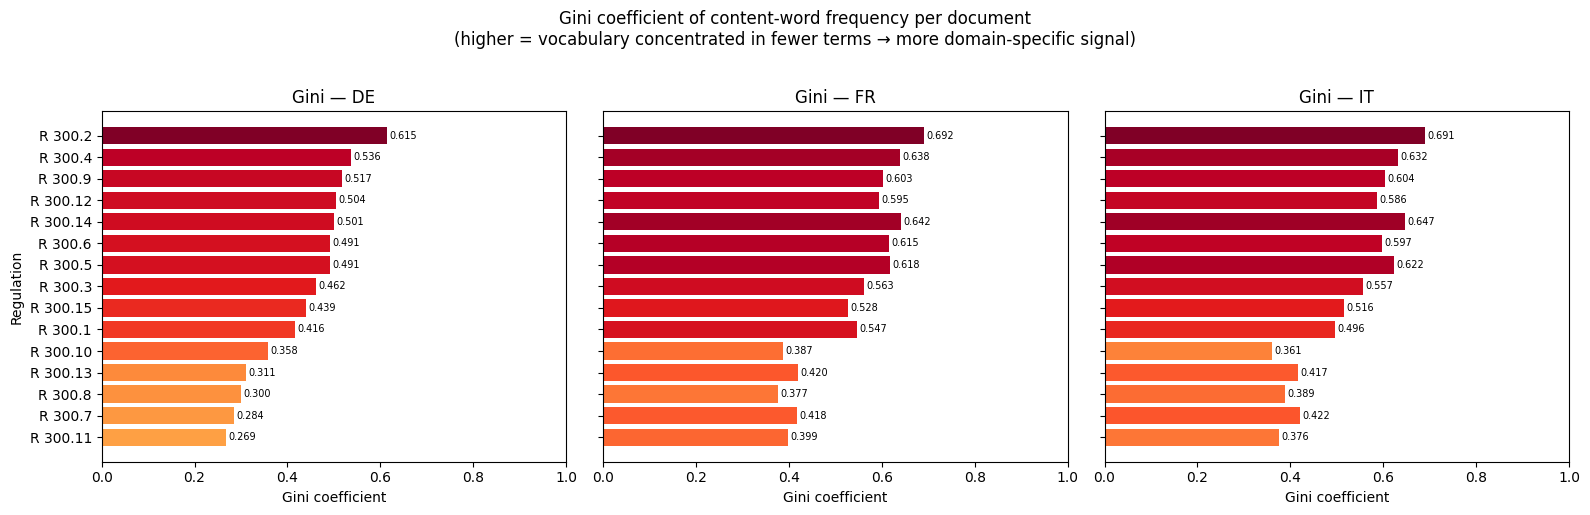

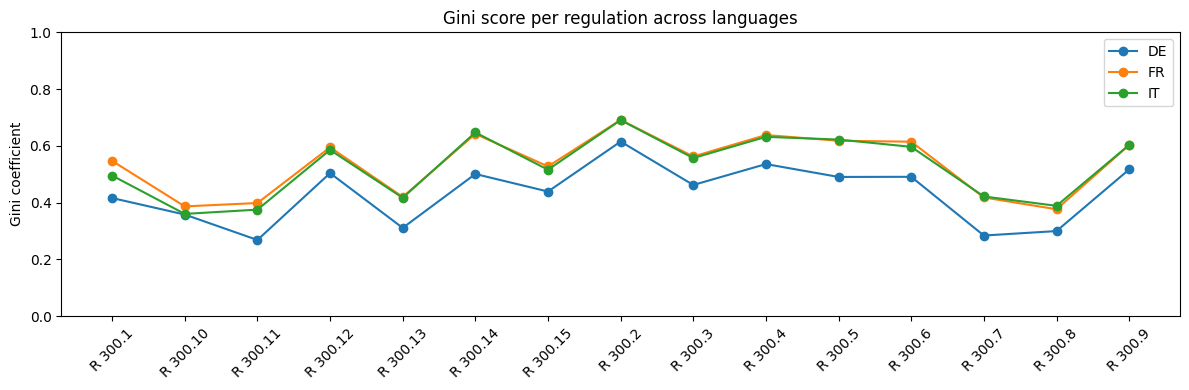


Summary — mean Gini per language:
            mean     min     max
language                        
DE        0.4331  0.2687  0.6153
FR        0.5362  0.3769  0.6916
IT        0.5275  0.3605  0.6909


In [21]:
def gini(freqs):
    """Gini coefficient of a frequency distribution (0 = uniform, 1 = maximally concentrated)."""
    arr = np.sort(np.array(freqs, dtype=float))
    n   = len(arr)
    if n == 0 or arr.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * arr) / (n * arr.sum())) - (n + 1) / n


gini_rows = []
for lang in LANGUAGES:
    for doc in docs_by_lang[lang]:
        tokens = tokenize(doc["text"])
        cw     = content_words(tokens, lang)
        if not cw:
            continue
        freq  = Counter(cw)
        score = gini(list(freq.values()))
        gini_rows.append({
            "language":      lang.upper(),
            "regulation":    doc["regulation_number"],
            "title":         doc["document_title"],
            "gini":          score,
            "unique_types":  len(freq),
            "total_tokens":  len(cw),
        })

df_gini = pd.DataFrame(gini_rows).sort_values(["language", "gini"], ascending=[True, False])
display(df_gini.style
        .format({"gini": "{:.4f}"})
        .background_gradient(subset=["gini"], cmap="YlOrRd")
        .hide(axis="index"))

# Per-language bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, lang in zip(axes, LANGUAGES):
    sub  = df_gini[df_gini["language"] == lang.upper()].sort_values("gini")
    norm = sub["gini"] / sub["gini"].max() if sub["gini"].max() > 0 else sub["gini"]
    bars = ax.barh(sub["regulation"], sub["gini"],
                   color=plt.cm.YlOrRd(norm))
    ax.set_title(f"Gini — {lang.upper()}")
    ax.set_xlabel("Gini coefficient")
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, sub["gini"]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=7)
axes[0].set_ylabel("Regulation")
plt.suptitle(
    "Gini coefficient of content-word frequency per document\n"
    "(higher = vocabulary concentrated in fewer terms → more domain-specific signal)",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Cross-language line comparison
fig, ax = plt.subplots(figsize=(12, 4))
for lang in LANGUAGES:
    sub = df_gini[df_gini["language"] == lang.upper()].sort_values("regulation")
    ax.plot(sub["regulation"], sub["gini"], marker="o", label=lang.upper())
ax.set_title("Gini score per regulation across languages")
ax.set_ylabel("Gini coefficient")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print("\nSummary — mean Gini per language:")
print(df_gini.groupby("language")["gini"].agg(["mean", "min", "max"]).round(4))

## Section 8 — Domain Specificity: FDV vs. Reference Corpus

Set `FETCH_WIKIPEDIA = True` in Section 0 to enable this section.


Fetching Wikipedia articles for DE...
    Wetter: 14,843 chars
    Geschichte_der_Schweiz: 137,943 chars
    Landwirtschaft: 37,268 chars
    Musik: 111,754 chars
    Schule: 39,165 chars
    Gesundheit: 10,554 chars
    Tourismus: 62,568 chars
    Literatur: 60,419 chars
    Sport: 20,950 chars
    Mathematik: 25,518 chars
  DE — top domain-specific terms:
   fahrt, gleis, fahrzeuge, weiche, strecke, bremsen, halt, signalen, bremse, züge, zustimmung, betriebsvorschriften, rangierbewegungen, arbeitsstelle, fahrzeug, fermata, hindernisses, geschwindigkeit, antworten, befahren, hauptsignal, triebfahrzeug, aufhebungssignal, ausgefahren, sicherheitsmassnahmen, rangierbewegung, dürfen, druckluft, verminderung, anhängelast


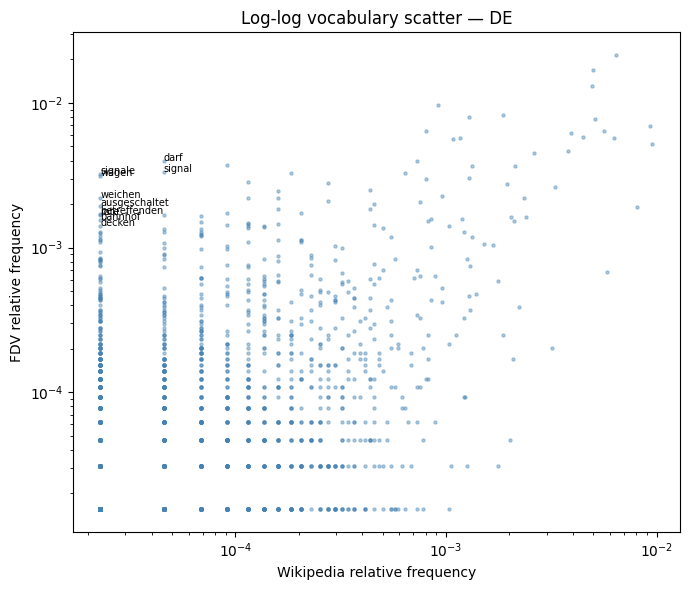


Fetching Wikipedia articles for FR...
    Histoire_de_la_Suisse: 48,439 chars
    Agriculture: 65,352 chars
    Musique: 57,142 chars
    %C3%89cole: 8,953 chars
    Sant%C3%A9: 19,515 chars
    Tourisme: 56,260 chars
    Litt%C3%A9rature: 27,454 chars
    Sport: 59,011 chars
    Math%C3%A9matiques: 51,576 chars
  FR — top domain-specific terms:
   signaux, frein, trains, manœuvre, véhicule, aiguille, conduite, freinage, freins, circuler, tramways, assentiment, convoi, prescriptions, cman, treni, fermata, tronçon, tronçons, chantier, aiguilles, cabine, franchissement, wagons, signalisation, préalable, indications, dispositif, surveillance, partiels


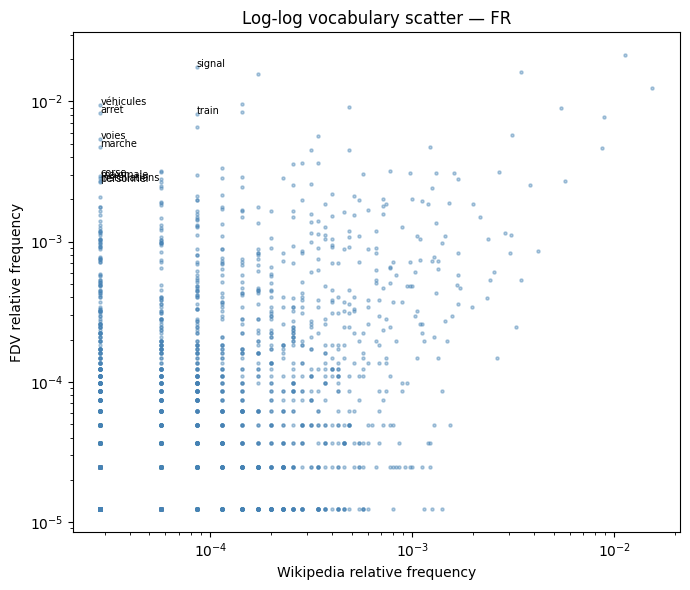


Fetching Wikipedia articles for IT...
    Meteo: 272 chars
    Storia_della_Svizzera: 34,125 chars
    Agricoltura: 24,577 chars
    Musica: 45,880 chars
    Scuola: 50,213 chars
    Salute: 13,439 chars
    Turismo: 25,601 chars
    Letteratura: 17,996 chars
    Sport: 30,839 chars
    Matematica: 24,168 chars
  IT — top domain-specific terms:
   segnale, segnali, binario, manovra, treni, fermata, cmov, cman, freni, frenatura, scambi, binari, condotta, veicolo, prescrizioni, scambio, stazione, segue, luce, avanzato, avviso, impianti, validità, dispositivo, marcia, commutazione, rallenta, contatto, allegato, rimorchiato


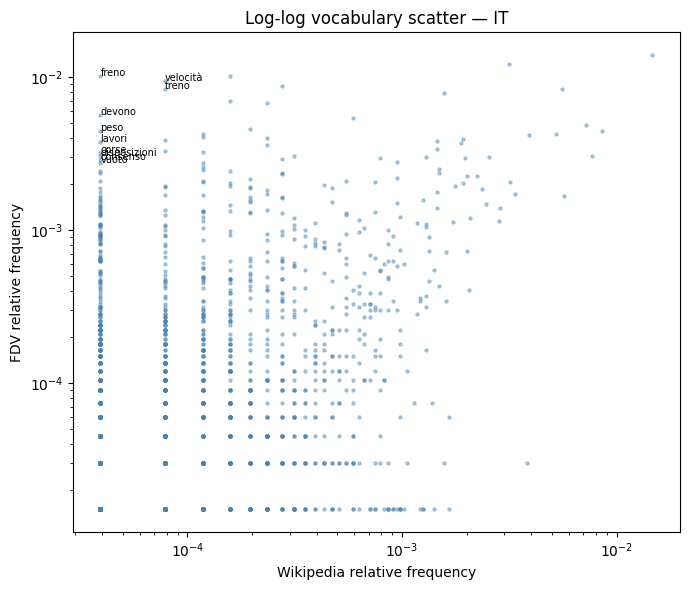


Vocabulary overlap summary


,Language,FDV vocab overlap with Wikipedia (%)
0,DE,22.1
1,FR,36.4
2,IT,33.1


In [15]:
WIKI_ARTICLES = {
    "de": [
        "Wetter", "Geschichte_der_Schweiz", "Landwirtschaft", "Musik",
        "Schule", "Gesundheit", "Tourismus", "Literatur", "Sport", "Mathematik",
    ],
    "fr": [
        "M%C3%A9t%C3%A9o", "Histoire_de_la_Suisse", "Agriculture", "Musique",
        "%C3%89cole", "Sant%C3%A9", "Tourisme", "Litt%C3%A9rature", "Sport", "Math%C3%A9matiques",
    ],
    "it": [
        "Meteo", "Storia_della_Svizzera", "Agricoltura", "Musica",
        "Scuola", "Salute", "Turismo", "Letteratura", "Sport", "Matematica",
    ],
}

def fetch_wikipedia_text(lang: str, title: str) -> str:
    url = (
        f"https://{lang}.wikipedia.org/w/api.php"
        f"?action=query&prop=extracts&explaintext=1"
        f"&titles={title}&format=json"
    )
    req = urllib.request.Request(url, headers={"User-Agent": "FDV-RAG-Explorer/1.0"})
    try:
        with urllib.request.urlopen(req, timeout=15) as r:
            data = json.loads(r.read().decode("utf-8"))
        pages = data["query"]["pages"]
        return next(iter(pages.values())).get("extract", "")
    except Exception as e:
        print(f"    Warning: could not fetch {lang}:{title} — {e}")
        return ""


if not FETCH_WIKIPEDIA:
    print("FETCH_WIKIPEDIA is False — set it to True in Section 0 to run this section.")
else:
    overlap_summary = []

    for lang in LANGUAGES:
        print(f"\nFetching Wikipedia articles for {lang.upper()}...")
        wiki_texts = []
        for title in WIKI_ARTICLES[lang]:
            text = fetch_wikipedia_text(lang, title)
            if text:
                wiki_texts.append(text)
                print(f"    {title}: {len(text):,} chars")

        if not wiki_texts:
            print(f"  No Wikipedia content fetched for {lang.upper()} — skipping domain analysis.")
            overlap_summary.append({"Language": lang.upper(), "FDV vocab overlap with Wikipedia (%)": "n/a"})
            continue

        wiki_tokens = tokenize(" ".join(wiki_texts))
        wiki_freq   = Counter(wiki_tokens)
        wiki_vocab  = set(wiki_tokens)
        wiki_total  = sum(wiki_freq.values())

        fdv_text    = " ".join(c["text"] for c in chunks_by_lang[lang])
        fdv_tokens  = tokenize(fdv_text)
        fdv_freq    = Counter(fdv_tokens)
        fdv_vocab   = set(fdv_tokens)
        fdv_total   = sum(fdv_freq.values())

        overlap_pct = 100 * len(fdv_vocab & wiki_vocab) / len(fdv_vocab)
        overlap_summary.append({"Language": lang.upper(), "FDV vocab overlap with Wikipedia (%)": f"{overlap_pct:.1f}"})

        # Keyness: log2 ratio of relative frequencies
        keyness = {}
        for w in fdv_vocab:
            f_fdv  = fdv_freq.get(w, 0) / fdv_total
            f_wiki = wiki_freq.get(w, 1e-9) / wiki_total
            keyness[w] = np.log2(f_fdv / f_wiki)

        top_key = sorted(keyness.items(), key=lambda x: x[1], reverse=True)[:30]
        print(f"  {lang.upper()} — top domain-specific terms:")
        print("  ", ", ".join(w for w, _ in top_key))

        # Log-log scatter
        common = fdv_vocab & wiki_vocab
        x_vals = [wiki_freq.get(w, 1) / wiki_total for w in common]
        y_vals = [fdv_freq.get(w, 1)  / fdv_total  for w in common]

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.scatter(x_vals, y_vals, s=5, alpha=0.4, color="steelblue")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Wikipedia relative frequency")
        ax.set_ylabel("FDV relative frequency")
        ax.set_title(f"Log-log vocabulary scatter — {lang.upper()}")
        keyness_common = {w: keyness[w] for w in common}
        for w, _ in sorted(keyness_common.items(), key=lambda x: x[1], reverse=True)[:10]:
            xi = wiki_freq.get(w, 1) / wiki_total
            yi = fdv_freq.get(w, 1)  / fdv_total
            ax.annotate(w, (xi, yi), fontsize=7)
        plt.tight_layout()
        plt.show()

    print("\n" + "="*50)
    print("Vocabulary overlap summary")
    display(pd.DataFrame(overlap_summary))